In [20]:
from pathlib import Path
import pandas as pd

# Locate "Research Data" root and then target only "Single Activity Data".
research_root = Path.cwd()
if not (research_root / "Single Activity Data").exists():
    research_root = Path.cwd() / "Research Data"

single_activity_root = research_root / "Single Activity Data"
rd_files = sorted(single_activity_root.rglob("range_doppler.csv"))

records = []
for csv_path in rd_files:
    rel_parts = csv_path.parent.relative_to(single_activity_root).as_posix().split("/")
    activity = rel_parts[0] if len(rel_parts) > 0 else "Unknown"
    session = csv_path.parent.name

    try:
        df = pd.read_csv(csv_path)
        if not {"frame_number", "timestamp_s"}.issubset(df.columns):
            df = pd.read_csv(
                csv_path,
                header=None,
                names=["timestamp_s", "frame_number", "range_bin", "doppler_bin", "signal_strength"],
            )

        df["frame_number"] = pd.to_numeric(df["frame_number"], errors="coerce")
        df["timestamp_s"] = pd.to_numeric(df["timestamp_s"], errors="coerce")
        df = df.dropna(subset=["frame_number", "timestamp_s"])

        frame_count = int(df["frame_number"].nunique()) if not df.empty else 0
        duration_s = float(df["timestamp_s"].max() - df["timestamp_s"].min()) if not df.empty else 0.0
    except Exception:
        frame_count = 0
        duration_s = 0.0

    records.append(
        {
            "Activity": activity,
            "Session": session,
            "Total Frames": frame_count,
            "Duration_s": round(duration_s, 3),
        }
    )

summary_table = pd.DataFrame(records)

if summary_table.empty:
    print("No range_doppler.csv found under Single Activity Data.")
else:
    session_order = pd.to_numeric(
        summary_table["Session"].astype(str).str.replace("m", "", regex=False).str.strip(),
        errors="coerce",
    )
    summary_table = (
        summary_table.assign(_session_order=session_order)
        .sort_values(["Activity", "_session_order", "Session"])
        .drop(columns=["_session_order"])
        .reset_index(drop=True)
    )

summary_table

,Activity,Session,Total Frames,Duration_s
0,Sitting,1m,27,30.997
1,Sitting,2m,36,40.819
2,Sitting,2.5m,26,30.003
3,Sitting,3m,40,44.001
4,Sitting,4.m,41,47.011
5,Standing,1m,43,47.995
6,Standing,2m,48,54.018
7,Standing,2.5m,43,50.019
8,Standing,3m,42,46.003
9,Standing,4.m,45,47.832


## Data description

link: https://docs.google.com/document/d/1X2GbykWLQlnttuWn8yi8y_jkvNyixsIJT8VYAbNi_2c/edit?usp=sharing


### Plotting Angle of Arrival AoA


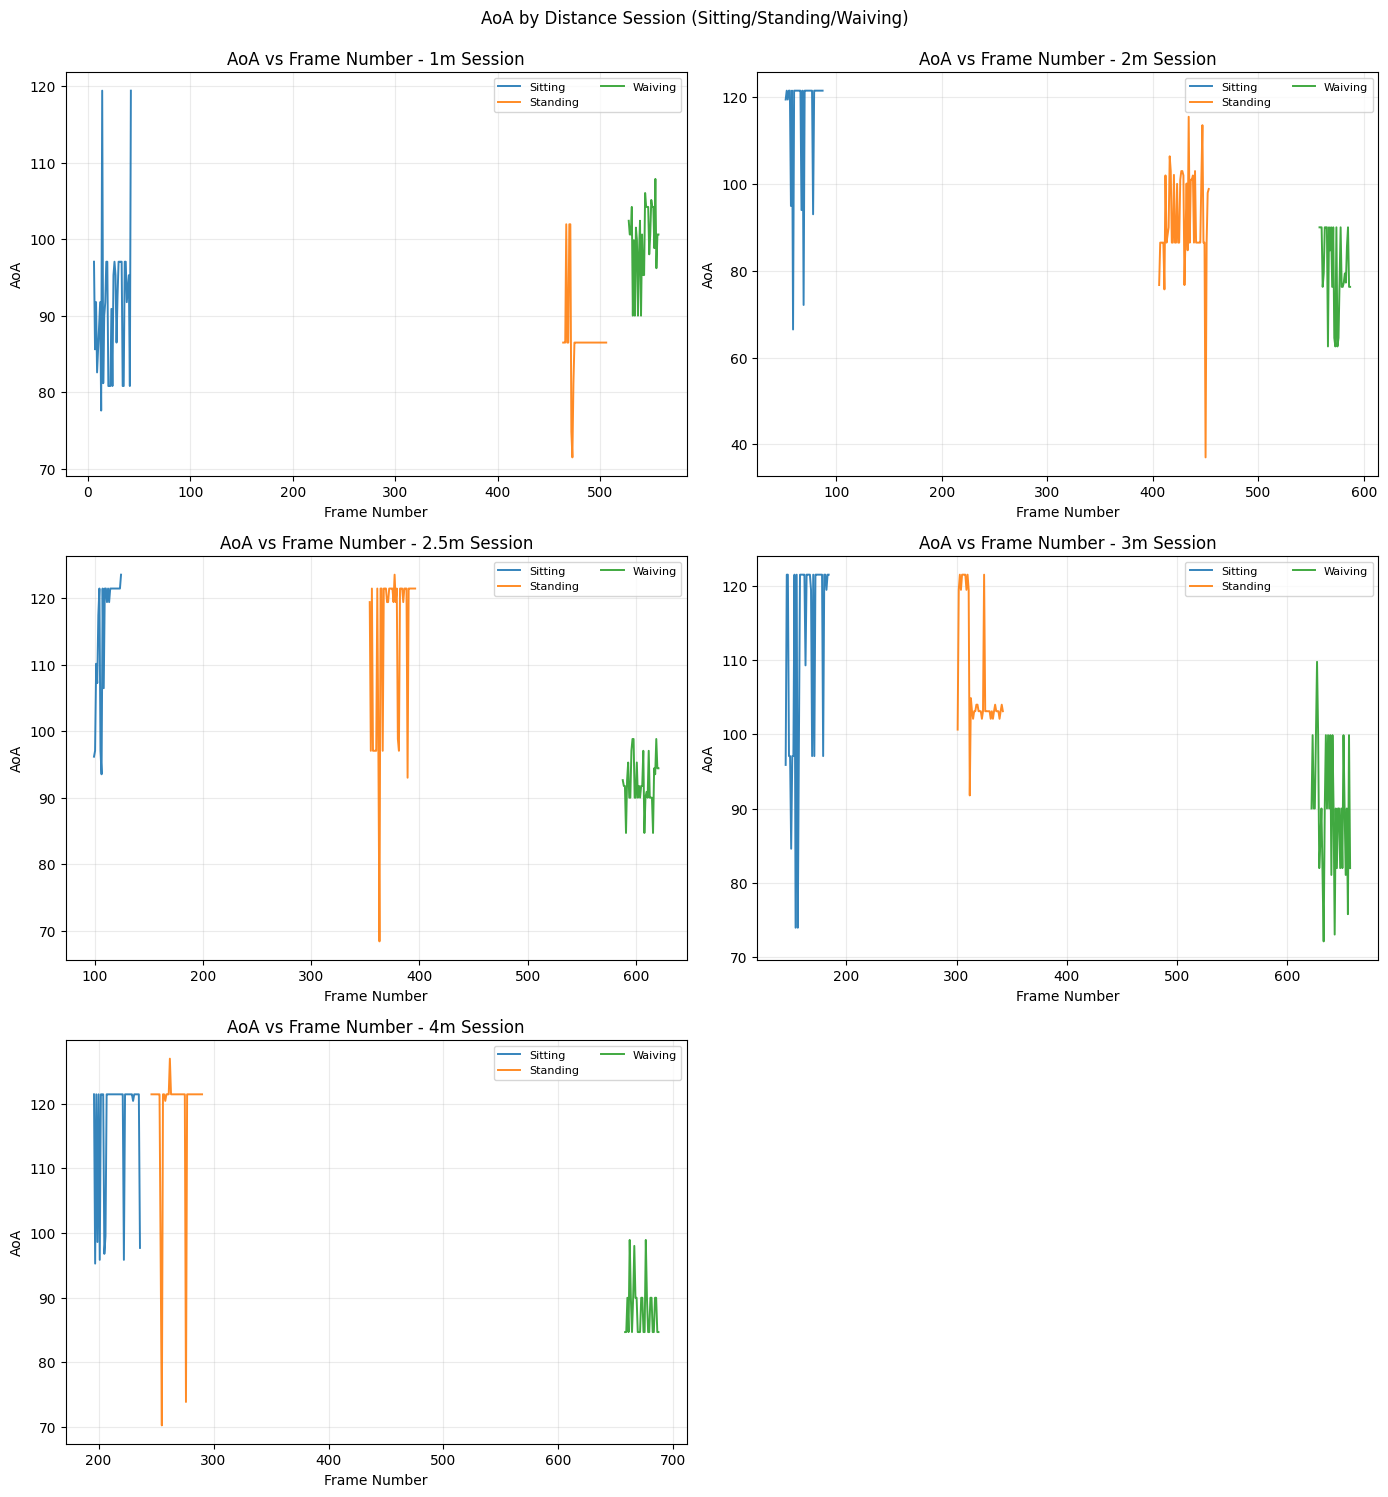

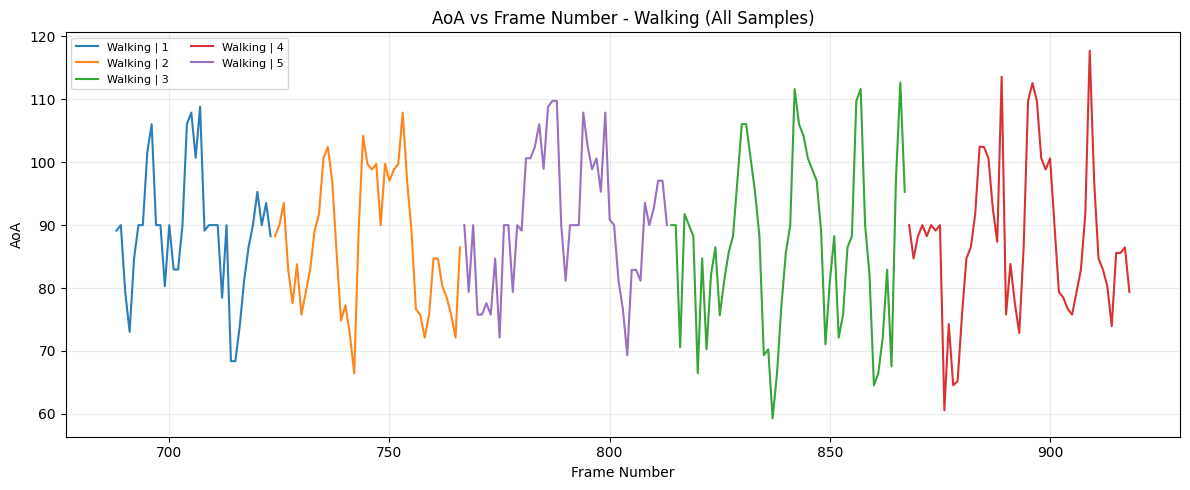

In [21]:
# AoA vs Frame Number by distance/session:
# 1) Combined-by-distance plots for Sitting/Standing/Waiving (exclude Walking)
# 2) Separate single plot for all Walking samples
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pc_files = sorted(single_activity_root.rglob("points_cloud.csv"))


def canonical_distance_label(raw):
    txt = str(raw).strip().lower().replace(" ", "")
    txt = txt.replace(".m", "m")
    if txt.endswith("m"):
        num_txt = txt[:-1]
    else:
        num_txt = txt

    try:
        val = float(num_txt)
        if abs(val - round(val)) < 1e-9:
            return f"{int(round(val))}m", val
        return f"{val:g}m", val
    except Exception:
        return str(raw), np.nan


session_curves = []
for pc_path in pc_files:
    rel_parts = pc_path.parent.relative_to(single_activity_root).as_posix().split("/")
    activity = rel_parts[0] if len(rel_parts) > 0 else "Unknown"
    raw_distance = rel_parts[1] if len(rel_parts) > 1 else pc_path.parent.name
    dist_label, dist_order = canonical_distance_label(raw_distance)

    try:
        df = pd.read_csv(pc_path)
        expected_cols = ["frame_number", "point_index", "x", "y", "z", "doppler", "range", "aoa"]
        if not {"frame_number", "aoa"}.issubset(df.columns):
            df = pd.read_csv(pc_path, header=None, names=expected_cols)

        df["frame_number"] = pd.to_numeric(df["frame_number"], errors="coerce")
        df["aoa"] = pd.to_numeric(df["aoa"], errors="coerce")
        clean = df.dropna(subset=["frame_number", "aoa"])
        if clean.empty:
            continue

        # Keep each file/sample separate; only summarize multiple points within same frame.
        curve = (
            clean.groupby("frame_number", as_index=False)["aoa"]
            .median()
            .sort_values("frame_number")
        )
        curve["Activity"] = activity
        curve["Distance"] = dist_label
        curve["DistanceOrder"] = dist_order
        curve["SampleKey"] = f"{activity} | {raw_distance}"
        session_curves.append(curve)
    except Exception as e:
        print(f"Skipping {pc_path}: {e}")

if not session_curves:
    print("No valid AoA data found in points_cloud.csv files.")
else:
    aoa_by_session_df = pd.concat(session_curves, ignore_index=True)

    # -----------------------------
    # A) Distance-wise combined plots (exclude walking)
    # -----------------------------
    non_walking_df = aoa_by_session_df[aoa_by_session_df["Activity"].str.lower() != "walking"].copy()

    if non_walking_df.empty:
        print("No non-walking data available for distance-wise combined plots.")
    else:
        distance_order_df = (
            non_walking_df[["Distance", "DistanceOrder"]]
            .drop_duplicates()
            .sort_values(["DistanceOrder", "Distance"], na_position="last")
        )
        distance_labels = distance_order_df["Distance"].tolist()

        n = len(distance_labels)
        cols = 2
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows), squeeze=False)

        activity_colors = {
            "Sitting": "tab:blue",
            "Standing": "tab:orange",
            "Waiving": "tab:green",
            "Waving": "tab:green",
        }

        for idx, dist in enumerate(distance_labels):
            r, c = divmod(idx, cols)
            ax = axes[r][c]

            subset = non_walking_df[non_walking_df["Distance"] == dist]

            for sample_key, s in subset.groupby("SampleKey", sort=True):
                act = s["Activity"].iloc[0]
                ax.plot(
                    s["frame_number"],
                    s["aoa"],
                    color=activity_colors.get(act, "gray"),
                    linewidth=1.4,
                    alpha=0.9,
                    label=act,
                )

            handles, labels = ax.get_legend_handles_labels()
            uniq = dict(zip(labels, handles))
            if uniq:
                ax.legend(uniq.values(), uniq.keys(), fontsize=8, ncol=2)
            ax.set_title(f"AoA vs Frame Number - {dist} Session")
            ax.set_xlabel("Frame Number")
            ax.set_ylabel("AoA")
            ax.grid(alpha=0.25)

        for idx in range(n, rows * cols):
            r, c = divmod(idx, cols)
            axes[r][c].axis("off")

        fig.suptitle("AoA by Distance Session (Sitting/Standing/Waiving)", y=0.995)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # B) Walking only: all random samples in one separate plot
    # -----------------------------
    walking_df = aoa_by_session_df[aoa_by_session_df["Activity"].str.lower() == "walking"].copy()

    if walking_df.empty:
        print("No walking samples found.")
    else:
        fig, ax = plt.subplots(figsize=(12, 5))

        walking_keys = sorted(walking_df["SampleKey"].dropna().unique().tolist())
        cmap = plt.get_cmap("tab10")

        for i, key in enumerate(walking_keys):
            s = walking_df[walking_df["SampleKey"] == key]
            ax.plot(
                s["frame_number"],
                s["aoa"],
                color=cmap(i % 10),
                linewidth=1.5,
                alpha=0.95,
                label=key,
            )

        ax.set_title("AoA vs Frame Number - Walking (All Samples)")
        ax.set_xlabel("Frame Number")
        ax.set_ylabel("AoA")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, ncol=2)
        plt.tight_layout()
        plt.show()

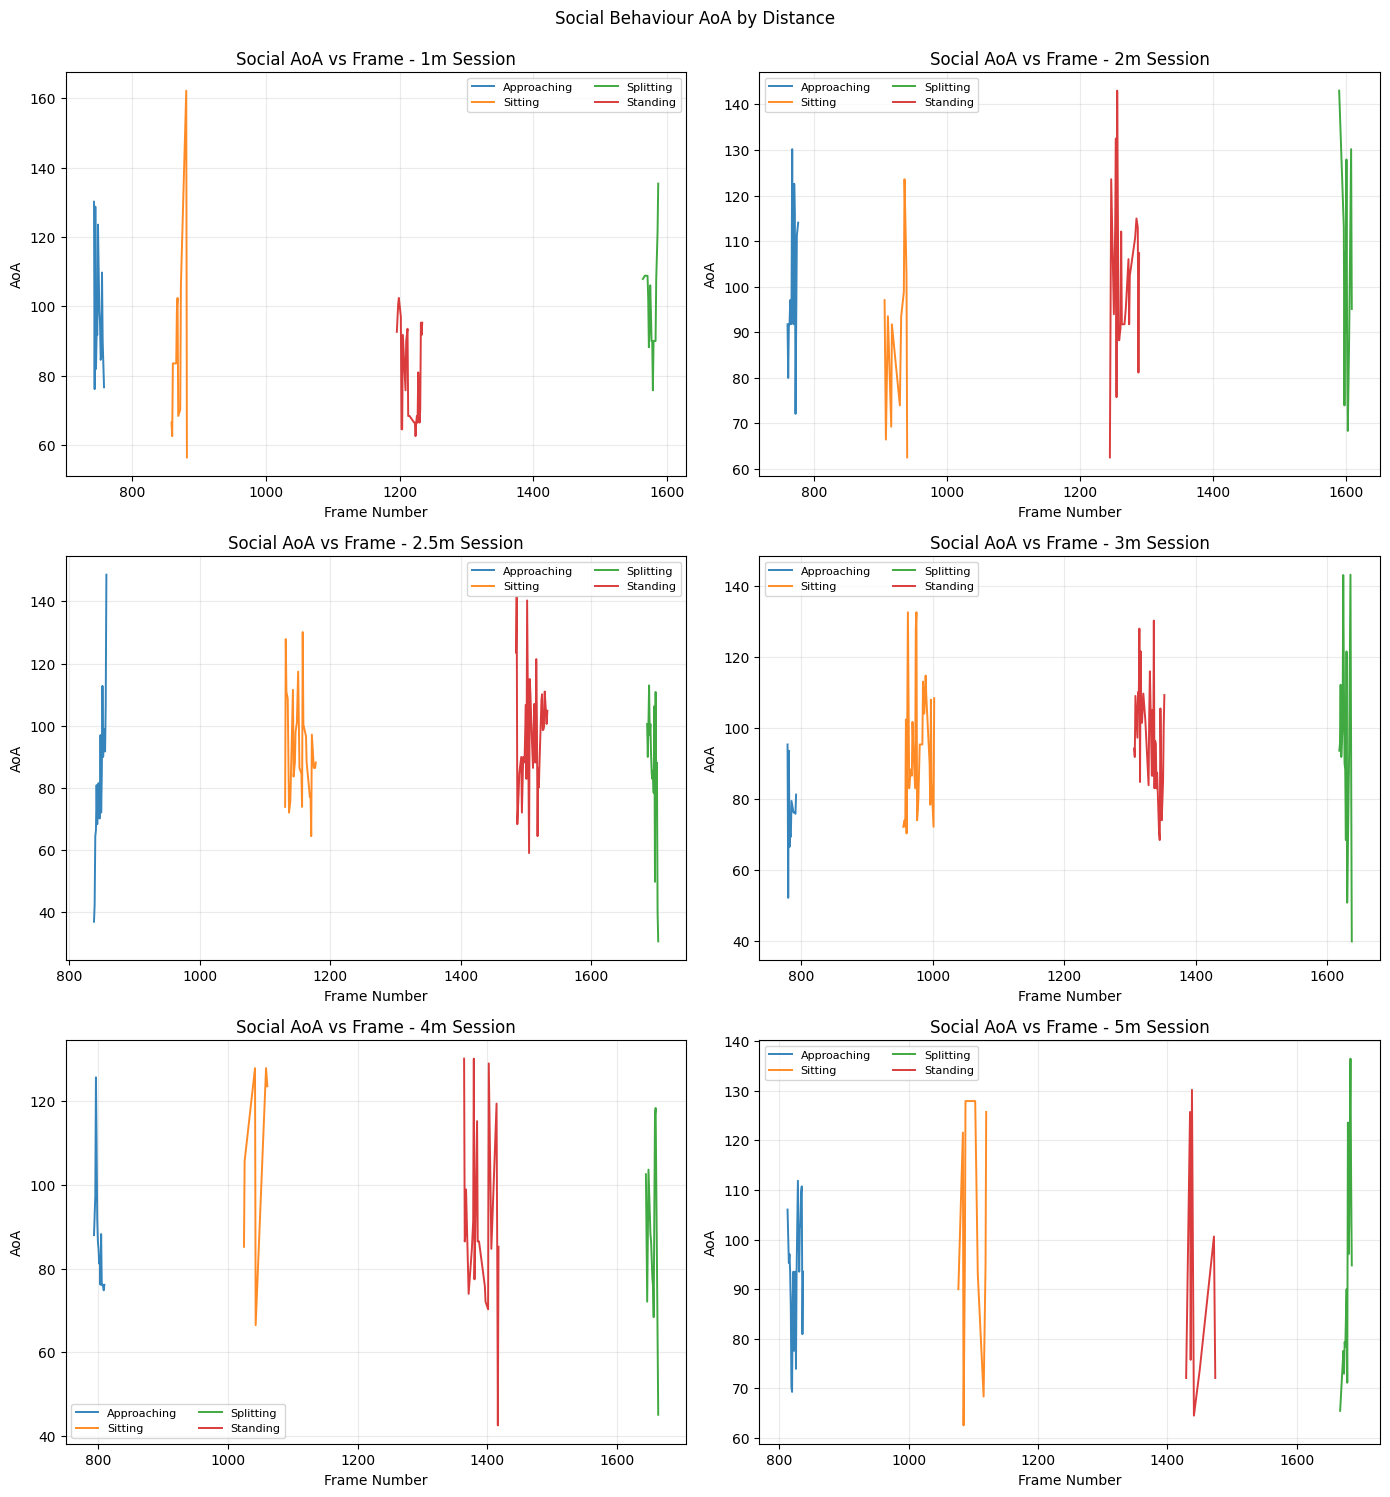

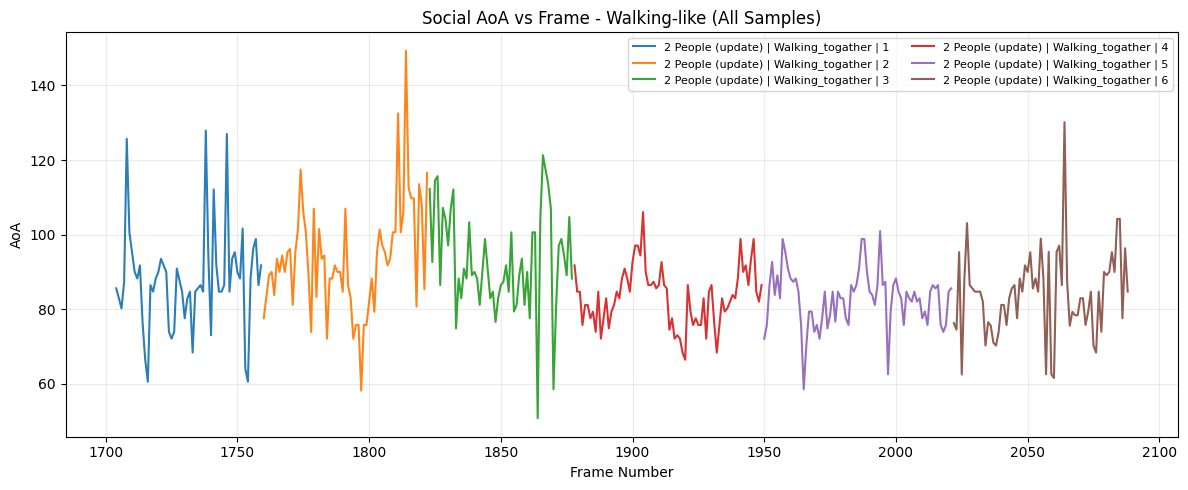

In [22]:
# AoA vs Frame Number for Social Behaviour data
# Same logic as Single Activity:
# 1) Distance-wise combined plots excluding walking-like activity
# 2) Separate plot for all walking-like samples
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

social_root = research_root / "Social Behaviour"
social_pc_files = sorted(social_root.rglob("points_cloud.csv")) if social_root.exists() else []


def canonical_distance_label(raw):
    txt = str(raw).strip().lower().replace(" ", "")
    txt = txt.replace(".m", "m")
    if txt.endswith("m"):
        num_txt = txt[:-1]
    else:
        num_txt = txt

    try:
        val = float(num_txt)
        if abs(val - round(val)) < 1e-9:
            return f"{int(round(val))}m", val
        return f"{val:g}m", val
    except Exception:
        return str(raw), np.nan


social_curves = []
for pc_path in social_pc_files:
    rel_parts = pc_path.parent.relative_to(social_root).as_posix().split("/")

    # Expected examples:
    # ["2 People (update)", "Approaching", "1m"]
    # ["2 People (update)", "Walking_togather", "4"]
    if len(rel_parts) >= 2:
        activity = rel_parts[-2]
        raw_distance = rel_parts[-1]
        group_name = rel_parts[0]
    else:
        activity = rel_parts[0] if rel_parts else "Unknown"
        raw_distance = pc_path.parent.name
        group_name = "UnknownGroup"

    dist_label, dist_order = canonical_distance_label(raw_distance)

    try:
        df = pd.read_csv(pc_path)
        expected_cols = ["frame_number", "point_index", "x", "y", "z", "doppler", "range", "aoa"]
        if not {"frame_number", "aoa"}.issubset(df.columns):
            df = pd.read_csv(pc_path, header=None, names=expected_cols)

        df["frame_number"] = pd.to_numeric(df["frame_number"], errors="coerce")
        df["aoa"] = pd.to_numeric(df["aoa"], errors="coerce")
        clean = df.dropna(subset=["frame_number", "aoa"])
        if clean.empty:
            continue

        curve = (
            clean.groupby("frame_number", as_index=False)["aoa"]
            .median()
            .sort_values("frame_number")
        )
        curve["Group"] = group_name
        curve["Activity"] = activity
        curve["Distance"] = dist_label
        curve["DistanceOrder"] = dist_order
        curve["SampleKey"] = f"{group_name} | {activity} | {raw_distance}"
        social_curves.append(curve)
    except Exception as e:
        print(f"Skipping {pc_path}: {e}")

if not social_curves:
    print("No valid Social Behaviour points_cloud.csv files found.")
else:
    social_aoa_df = pd.concat(social_curves, ignore_index=True)

    # Walking-like activities handled separately.
    is_walking_like = social_aoa_df["Activity"].str.lower().str.contains("walking", na=False)

    # -----------------------------
    # A) Distance-wise combined plots (exclude walking-like)
    # -----------------------------
    social_non_walking_df = social_aoa_df[~is_walking_like].copy()

    if social_non_walking_df.empty:
        print("No non-walking social behaviour data available for distance-wise combined plots.")
    else:
        distance_order_df = (
            social_non_walking_df[["Distance", "DistanceOrder"]]
            .drop_duplicates()
            .sort_values(["DistanceOrder", "Distance"], na_position="last")
        )
        distance_labels = distance_order_df["Distance"].tolist()

        activity_order = sorted(social_non_walking_df["Activity"].dropna().unique().tolist())
        palette = plt.get_cmap("tab10")
        activity_colors = {act: palette(i % 10) for i, act in enumerate(activity_order)}

        n = len(distance_labels)
        cols = 2
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows), squeeze=False)

        for idx, dist in enumerate(distance_labels):
            r, c = divmod(idx, cols)
            ax = axes[r][c]

            subset = social_non_walking_df[social_non_walking_df["Distance"] == dist]
            for sample_key, s in subset.groupby("SampleKey", sort=True):
                act = s["Activity"].iloc[0]
                ax.plot(
                    s["frame_number"],
                    s["aoa"],
                    color=activity_colors.get(act, "gray"),
                    linewidth=1.4,
                    alpha=0.9,
                    label=act,
                )

            handles, labels = ax.get_legend_handles_labels()
            uniq = dict(zip(labels, handles))
            if uniq:
                ax.legend(uniq.values(), uniq.keys(), fontsize=8, ncol=2)
            ax.set_title(f"Social AoA vs Frame - {dist} Session")
            ax.set_xlabel("Frame Number")
            ax.set_ylabel("AoA")
            ax.grid(alpha=0.25)

        for idx in range(n, rows * cols):
            r, c = divmod(idx, cols)
            axes[r][c].axis("off")

        fig.suptitle("Social Behaviour AoA by Distance", y=0.995)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # B) Walking-like only: separate plot with all samples
    # -----------------------------
    social_walking_df = social_aoa_df[is_walking_like].copy()

    if social_walking_df.empty:
        print("No walking-like social behaviour samples found.")
    else:
        fig, ax = plt.subplots(figsize=(12, 5))

        walking_keys = sorted(social_walking_df["SampleKey"].dropna().unique().tolist())
        cmap = plt.get_cmap("tab10")

        for i, key in enumerate(walking_keys):
            s = social_walking_df[social_walking_df["SampleKey"] == key]
            ax.plot(
                s["frame_number"],
                s["aoa"],
                color=cmap(i % 10),
                linewidth=1.5,
                alpha=0.95,
                label=key,
            )

        ax.set_title("Social AoA vs Frame - Walking-like (All Samples)")
        ax.set_xlabel("Frame Number")
        ax.set_ylabel("AoA")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8, ncol=2)
        plt.tight_layout()
        plt.show()

## Range-Doppler Activity Modeling (LSTM + CNN)

This section uses only `range_doppler.csv` from **Single Activity Data**.

Workflow:
1. EDA and sanity checks
2. Preprocessing and train/test split (3 samples train + 2 samples test per activity)
3. Train LSTM model
4. Train CNN model
5. Show confusion matrix, loss/accuracy curves, and a result summary table

Loaded samples: 20


,activity,sample,n_frames,shape
0,Sitting,1m,27,"(64, 128)"
1,Sitting,2.5m,26,"(64, 128)"
2,Sitting,2m,36,"(64, 128)"
3,Sitting,3m,40,"(64, 128)"
4,Sitting,4.m,41,"(64, 128)"
5,Standing,1m,43,"(64, 128)"
6,Standing,2.5m,43,"(64, 128)"
7,Standing,2m,48,"(64, 128)"
8,Standing,3m,42,"(64, 128)"
9,Standing,4.m,45,"(64, 128)"


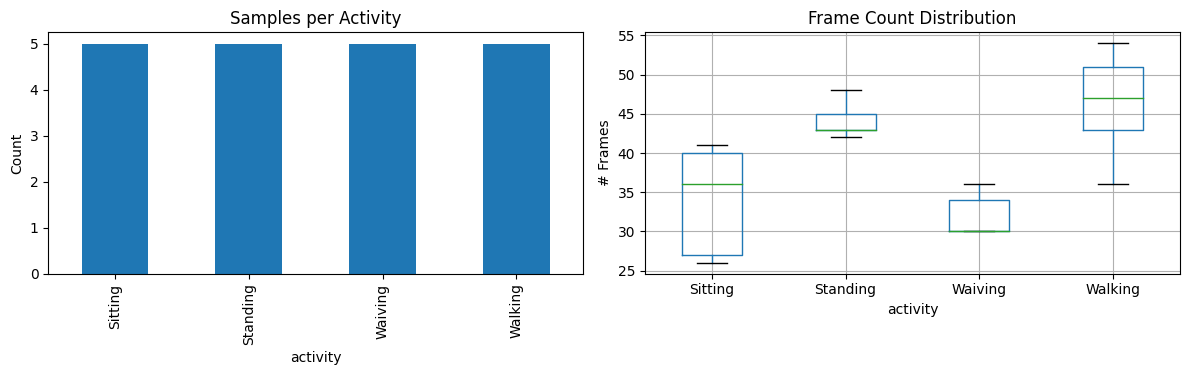

In [23]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

rd_root = single_activity_root
rd_files = sorted(rd_root.rglob("range_doppler.csv"))


def load_range_doppler_frames(csv_path: Path):
    """Return frames as [num_frames, range_bins, doppler_bins] and sorted frame numbers."""
    df = pd.read_csv(csv_path)
    required = {"frame_number", "range_bin", "doppler_bin", "signal_strength"}

    if not required.issubset(df.columns):
        raw = pd.read_csv(csv_path, header=None)
        if raw.shape[1] >= 5:
            raw = raw.iloc[:, :5].copy()
            raw.columns = ["timestamp", "frame_number", "range_bin", "doppler_bin", "signal_strength"]
        elif raw.shape[1] == 4:
            raw.columns = ["frame_number", "range_bin", "doppler_bin", "signal_strength"]
        else:
            return None, None
        df = raw

    for col in ["frame_number", "range_bin", "doppler_bin", "signal_strength"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["frame_number", "range_bin", "doppler_bin", "signal_strength"])
    if df.empty:
        return None, None

    max_r = int(df["range_bin"].max()) + 1
    max_d = int(df["doppler_bin"].max()) + 1

    frames = []
    frame_ids = sorted(df["frame_number"].astype(int).unique().tolist())
    g = df.groupby("frame_number")
    for f in frame_ids:
        part = g.get_group(f)
        mat = np.zeros((max_r, max_d), dtype=np.float32)
        r = part["range_bin"].astype(int).to_numpy()
        d = part["doppler_bin"].astype(int).to_numpy()
        s = part["signal_strength"].astype(np.float32).to_numpy()
        mat[r, d] = s
        mat = np.fft.fftshift(mat, axes=1)
        frames.append(mat)

    return np.stack(frames, axis=0), frame_ids


def resize_frame(frame_2d, target_hw=(32, 32)):
    ry = target_hw[0] / frame_2d.shape[0]
    rx = target_hw[1] / frame_2d.shape[1]
    return zoom(frame_2d, (ry, rx), order=1).astype(np.float32)


records = []
for p in rd_files:
    rel = p.parent.relative_to(rd_root).as_posix().split("/")
    activity = rel[0] if len(rel) > 0 else "Unknown"
    sample = rel[1] if len(rel) > 1 else p.parent.name

    frames, frame_ids = load_range_doppler_frames(p)
    if frames is None:
        continue

    records.append(
        {
            "activity": activity,
            "sample": sample,
            "csv_path": p,
            "n_frames": int(frames.shape[0]),
            "shape": tuple(frames.shape[1:]),
            "frames": frames,
            "frame_ids": frame_ids,
        }
    )

meta_df = pd.DataFrame(records)
print("Loaded samples:", len(meta_df))
display(meta_df[["activity", "sample", "n_frames", "shape"]].sort_values(["activity", "sample"]).reset_index(drop=True))

# EDA plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
meta_df.groupby("activity")["sample"].count().sort_index().plot(kind="bar", ax=axes[0], title="Samples per Activity")
axes[0].set_ylabel("Count")
meta_df.boxplot(column="n_frames", by="activity", ax=axes[1])
axes[1].set_title("Frame Count Distribution")
axes[1].set_ylabel("# Frames")
plt.suptitle("")
plt.tight_layout()
plt.show()

## SingleActivity Classification Pipeline

This section rebuilds the workflow in a clean order:

1. Preprocess range-doppler data
2. Explain the preprocessing output
3. Train LSTM model for activity classification
4. Train CNN model for activity classification
5. Combine LSTM + CNN predictions for final activity classification

###  Processed Before Training (Detailed, Term-by-Term)


1. Input and Parsing

- Input files: `range_doppler.csv` from each activity/session folder in `Single Activity Data`.
- Required columns:
  - `frame_number`: time index of a radar frame.
  - `range_bin`: spatial bin index along range axis (distance direction).
  - `doppler_bin`: velocity bin index along Doppler axis (radial speed direction).
  - `signal_strength`: intensity/magnitude at one `(range_bin, doppler_bin)` location.
- What the code does:
  - `rd_read_longform(...)` loads CSV and enforces numeric types.
  - `rd_parse_heatmaps(...)` reconstructs each frame into a 2D matrix `mat[range_bin, doppler_bin]`.
- Why: models require a consistent numeric tensor, not raw long-form rows.


2. Frame Matrix Construction

- Term: frame heatmap
  - A single radar frame represented as a 2D array of shape `[R, D]`, where:
    - `R = max(range_bin)+1`
    - `D = max(doppler_bin)+1`
- Code behavior:
  - Initialize zeros matrix for each frame.
  - Fill matrix using observed bins and their `signal_strength` values.
- Why: this converts sparse event records into image-like structure suitable for signal processing and deep learning.



3. Anomaly Screening (Noise/Outlier Rejection)

Function used: `rd_filter_anomalous(heatmaps, frame_nums)`

3.1 Per-frame summary terms

- `mean`: average signal value in one frame.
- `std`: standard deviation of frame values (spread/variability).
- `peak`: maximum signal value in one frame.
- `sat`: number of bins in a frame with value `> 60000`.

3.2 Hard gates used in code

- `sat > 0`
  - Meaning: at least one bin is above 60000 (near ceiling behavior).
  - Why: catches near-saturation/clipping-like points.
- `peak > 10000`
  - Meaning: frame has unusually high single-bin maximum.
  - Why: removes spike-dominant frames that may be artifacts.
- `std > 2000`
  - Meaning: frame-wide signal spread is very large.
  - Why: removes globally unstable/noisy frames.

3.3 Robust z-score gate

- Function: `robust_abs_z(v)`
- Formula used in code:
  - `z = abs((x - median) / (1.4826 * MAD))`
  - where `MAD = median(abs(x - median(x)))`
- Applied to `means`, `stds`, `peaks` as `zm`, `zs`, `zp`.
- Joint rule: frame is flagged when `(zp > 12) & (zs > 12) & (zm > 12)`.
- Why joint rule: avoid dropping frames due to one noisy metric alone; drop only frames that are jointly extreme across multiple statistics.

3.4 Final bad-frame rule

- Code logic:
  - `bad = (sat > 0) | (peak > 10000) | (std > 2000) | joint_robust_rule`
- Kept frames: frames where `bad == False`.
- Removed frames: frame numbers where `bad == True`.
- Why: improves signal quality before resizing and learning.



4. Playback-Style Per-frame Transform

Function: `rd_preprocess_frame(frame_2d, grid_size=250, min_value=2048, max_value=4096)`

4.1 `fftshift` on Doppler axis

- Code: `np.fft.fftshift(frame_2d, axes=1)`
- Meaning: re-centers Doppler bins so near-zero Doppler sits in center and positive/negative sides are arranged symmetrically.
- Why: standard spectral layout that is easier for model patterns to learn consistently.

4.2 Interpolation to fixed grid

- Target: at least `250 x 250` per frame (`PLAYBACK_GRID_SIZE`).
- Code uses `scipy.ndimage.zoom` with linear interpolation (`order=1`).
- Why: all frames must share common spatial dimensions for batching and CNN/LSTM input pipelines.

4.3 Min-max normalization

- Code: `(interp - 2048) / (4096 - 2048)` then clip to `[0, 1]`.
- Meaning: maps amplitude range into normalized scale.
- Why: stabilizes optimization and keeps values in controlled dynamic range.


5. Sequence-level Refinement

Function: `refine_sequence(frames_3d)` where shape is `[T, H, W]`.

5.1 Clip to `[0, 1]`

- Ensures no numeric overflow/out-of-range after prior transform.

5.2 Stationary clutter suppression

- Code: `x = x - median(x, axis=2, keepdims=True)`
- Meaning: subtract Doppler-axis median per row.
- Why: reduces static/background components and emphasizes motion-related variation.

5.3 Robust percentile scaling

- Compute `lo = percentile(x, 1)` and `hi = percentile(x, 99)`.
- Rescale: `(x - lo) / (hi - lo + eps)`, then clip to `[0, 1]`.
- Why: suppresses outlier influence while preserving most informative structure.



6. Train/Test Split by Session

- Group by activity.
- Convert session labels to sortable numeric order (`session_num`).
- Split policy in code: first 3 sessions -> train, remaining 2 -> test.
- Why: evaluates generalization across sessions instead of mixing all windows randomly.


7. Temporal Windowing

Function: `make_windows(frames_3d, seq_len=8, stride=2)`

- `seq_len = 8`: each training sample contains 8 consecutive frames.
- `stride = 2`: overlap between windows (start moves by 2 frames).
- Example windows: `[0..7], [2..9], [4..11], ...`
- Why: captures short temporal dynamics while increasing sample count from limited sessions.


8. Standardization (Using Train Statistics Only)

- Compute on train windows only:
  - `mu = mean(X_seq_train)`
  - `sigma = std(X_seq_train) + 1e-6`
- Apply to both sets:
  - `X = (X - mu) / sigma`
- Why:
  - centers/scales data for stable training,
  - avoids test leakage (test data does not define normalization stats).



9. Spatial Resize for Model Inputs

Function: `resize_seq_batch(..., target_hw=(64, 64))`

- Converts each frame in each window to `64 x 64`.
- Why: reduces memory/compute cost and gives fixed shape for neural networks.



10. LSTM Input Tensor Definition

- After resize, sequence shape is `[N, T, 64, 64]`.
- LSTM input is flattened per frame: `[N, T, 64*64]`.
- Meaning: each time step is a feature vector from one frame.
- Why: LSTM models temporal evolution of frame-level features.


11. CNN Input Tensor Definition (2-channel summary)

From resized sequence:

- Motion channel:
  - `mean(abs(diff over time)))`
  - Captures how strongly the frame content changes across adjacent time steps.
- Energy channel:
  - `max over time`
  - Captures strongest activation pattern seen in the window.
- Stacked CNN input shape: `[N, 64, 64, 2]`.
- Why: gives CNN a compact spatial representation of temporal behavior.


12. Label Encoding

- Activity names -> integer class IDs with `LabelEncoder`.
- One-hot encoding for training targets with `to_categorical`.
- Why: neural classifier outputs class probabilities; one-hot labels match categorical cross-entropy loss.


13. Why This Full Pipeline Exists

- Raw CSV rows are sparse and noisy.
- Models need fixed-shape, normalized, denoised tensors.
- The pipeline enforces:
  - consistent shape,
  - robust filtering of corrupted frames,
  - temporal structure extraction,
  - leakage-safe train/test normalization,
  - model-specific tensor formatting (LSTM vs CNN).

Net effect: cleaner and more learnable activity signatures before classification.

In [24]:
# Step 1: Build cleaned and standardized dataset from Single Activity range_doppler.csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import zoom
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

PLAYBACK_MIN_VALUE = 2048.0
PLAYBACK_MAX_VALUE = 4096.0
PLAYBACK_GRID_SIZE = 250
SEQ_LEN = 8
STRIDE = 2
TARGET_HW = (64, 64)

sa_root = single_activity_root
sa_files = sorted(sa_root.rglob("range_doppler.csv"))

def rd_read_longform(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    needed = {"frame_number", "range_bin", "doppler_bin", "signal_strength"}
    if not needed.issubset(df.columns):
        raw = pd.read_csv(csv_path, header=None)
        if raw.shape[1] >= 5:
            raw = raw.iloc[:, :5].copy()
            raw.columns = ["timestamp", "frame_number", "range_bin", "doppler_bin", "signal_strength"]
        elif raw.shape[1] == 4:
            raw.columns = ["frame_number", "range_bin", "doppler_bin", "signal_strength"]
        else:
            raise ValueError(f"Unexpected CSV layout: {csv_path}")
        df = raw

    for c in ["frame_number", "range_bin", "doppler_bin", "signal_strength"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["frame_number", "range_bin", "doppler_bin", "signal_strength"])
    return df

def rd_parse_heatmaps(df: pd.DataFrame):
    max_r = int(df["range_bin"].max()) + 1
    max_d = int(df["doppler_bin"].max()) + 1
    heatmaps, frame_nums = [], []
    g = df.groupby("frame_number")
    for frame_num in sorted(g.groups.keys()):
        part = g.get_group(frame_num)
        mat = np.zeros((max_r, max_d), dtype=np.float32)
        r = part["range_bin"].astype(int).to_numpy()
        d = part["doppler_bin"].astype(int).to_numpy()
        s = part["signal_strength"].astype(np.float32).to_numpy()
        mat[r, d] = s
        heatmaps.append(mat)
        frame_nums.append(int(frame_num))
    return heatmaps, frame_nums

def rd_filter_anomalous(heatmaps, frame_nums):
    if len(heatmaps) < 5:
        return heatmaps, []

    means = np.array([h.mean() for h in heatmaps], dtype=np.float32)
    stds = np.array([h.std() for h in heatmaps], dtype=np.float32)
    peaks = np.array([h.max() for h in heatmaps], dtype=np.float32)
    sat = np.array([(h > 60000).sum() for h in heatmaps], dtype=np.float32)

    def robust_abs_z(v):
        med = np.median(v)
        mad = np.median(np.abs(v - med))
        if mad < 1e-9:
            return np.zeros_like(v)
        return np.abs((v - med) / (1.4826 * mad))

    zm = robust_abs_z(means)
    zs = robust_abs_z(stds)
    zp = robust_abs_z(peaks)

    bad = (sat > 0) | (peaks > 10000) | (stds > 2000) | ((zp > 12.0) & (zs > 12.0) & (zm > 12.0))
    keep = [h for i, h in enumerate(heatmaps) if not bad[i]]
    removed = [int(frame_nums[i]) for i in range(len(frame_nums)) if bad[i]]
    return keep, removed

def rd_preprocess_frame(frame_2d, grid_size=250, min_value=2048.0, max_value=4096.0):
    shifted = np.fft.fftshift(frame_2d, axes=1)
    rows = max(grid_size, shifted.shape[0])
    cols = max(grid_size, shifted.shape[1])
    sy = rows / shifted.shape[0]
    sx = cols / shifted.shape[1]
    interp = zoom(shifted, (sy, sx), order=1)
    norm = (interp - min_value) / (max_value - min_value + 1e-9)
    norm = np.clip(norm, 0.0, 1.0)
    return norm.astype(np.float32)

def refine_sequence(frames_3d):
    x = np.asarray(frames_3d, dtype=np.float32)
    x = np.clip(x, 0.0, 1.0)
    x = x - np.median(x, axis=2, keepdims=True)
    lo = np.percentile(x, 1.0)
    hi = np.percentile(x, 99.0)
    x = (x - lo) / (hi - lo + 1e-6)
    x = np.clip(x, 0.0, 1.0)
    return x.astype(np.float32)

def make_windows(frames_3d, seq_len=8, stride=2):
    out = []
    if frames_3d.shape[0] < seq_len:
        return out
    for s in range(0, frames_3d.shape[0] - seq_len + 1, stride):
        out.append(frames_3d[s:s + seq_len])
    return out

records = []
for csv_path in sa_files:
    rel = csv_path.parent.relative_to(sa_root).as_posix().split("/")
    activity = rel[0] if len(rel) > 0 else "Unknown"
    session = rel[1] if len(rel) > 1 else csv_path.parent.name
    try:
        df = rd_read_longform(csv_path)
        heatmaps, frame_nums = rd_parse_heatmaps(df)
        filt, removed = rd_filter_anomalous(heatmaps, frame_nums)
        if len(filt) == 0:
            continue
        proc = [
            rd_preprocess_frame(
                h,
                grid_size=PLAYBACK_GRID_SIZE,
                min_value=PLAYBACK_MIN_VALUE,
                max_value=PLAYBACK_MAX_VALUE,
            )
            for h in filt
        ]
        frame_maps = refine_sequence(np.stack(proc, axis=0))
        records.append({
            "activity": activity,
            "session": session,
            "n_frames_raw": len(heatmaps),
            "n_frames_removed": len(removed),
            "n_frames_kept": len(filt),
            "frame_maps": frame_maps,
        })
    except Exception as e:
        print(f"Skip {csv_path}: {e}")

sa_df = pd.DataFrame(records)
if sa_df.empty:
    raise ValueError("No valid range-doppler samples found.")

split_rows = []
for act, g in sa_df.groupby("activity"):
    gg = g.copy()
    gg["session_num"] = pd.to_numeric(gg["session"].astype(str).str.replace("m", "", regex=False), errors="coerce")
    gg = gg.sort_values(["session_num", "session"], na_position="last").reset_index(drop=True)
    if len(gg) < 5:
        raise ValueError(f"Activity '{act}' has {len(gg)} sessions; minimum 5 is required.")
    gg["split"] = ["train" if i < 3 else "test" for i in range(len(gg))]
    split_rows.append(gg)
split_df = pd.concat(split_rows, ignore_index=True)

X_seq_train, y_train = [], []
X_seq_test, y_test = [], []

for _, row in split_df.iterrows():
    windows = make_windows(row["frame_maps"], seq_len=SEQ_LEN, stride=STRIDE)
    if not windows:
        continue
    if row["split"] == "train":
        X_seq_train.extend(windows)
        y_train.extend([row["activity"]] * len(windows))
    else:
        X_seq_test.extend(windows)
        y_test.extend([row["activity"]] * len(windows))

X_seq_train = np.asarray(X_seq_train, dtype=np.float32)
X_seq_test = np.asarray(X_seq_test, dtype=np.float32)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

mu = X_seq_train.mean()
sigma = X_seq_train.std() + 1e-6
X_seq_train = (X_seq_train - mu) / sigma
X_seq_test = (X_seq_test - mu) / sigma

def resize_seq_batch(x_seq, target_hw=(64, 64)):
    n, t, h, w = x_seq.shape
    sy = target_hw[0] / h
    sx = target_hw[1] / w
    out = np.empty((n, t, target_hw[0], target_hw[1]), dtype=np.float32)
    for i in range(n):
        for j in range(t):
            out[i, j] = zoom(x_seq[i, j], (sy, sx), order=1)
    return out

X_seq_train_rs = resize_seq_batch(X_seq_train, TARGET_HW)
X_seq_test_rs = resize_seq_batch(X_seq_test, TARGET_HW)

X_lstm_train = X_seq_train_rs.reshape((X_seq_train_rs.shape[0], X_seq_train_rs.shape[1], -1))
X_lstm_test = X_seq_test_rs.reshape((X_seq_test_rs.shape[0], X_seq_test_rs.shape[1], -1))

X_motion_train = np.mean(np.abs(np.diff(X_seq_train_rs, axis=1)), axis=1)
X_motion_test = np.mean(np.abs(np.diff(X_seq_test_rs, axis=1)), axis=1)
X_energy_train = np.max(X_seq_train_rs, axis=1)
X_energy_test = np.max(X_seq_test_rs, axis=1)
X_cnn_train = np.stack([X_motion_train, X_energy_train], axis=-1).astype(np.float32)
X_cnn_test = np.stack([X_motion_test, X_energy_test], axis=-1).astype(np.float32)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)
y_train_ohe = tf.keras.utils.to_categorical(y_train_enc, num_classes)
y_test_ohe = tf.keras.utils.to_categorical(y_test_enc, num_classes)

prep_report = split_df[["activity", "session", "n_frames_raw", "n_frames_removed", "n_frames_kept", "split"]].copy()
display(prep_report.sort_values(["activity", "session"]).reset_index(drop=True))
print("Classes:", list(le.classes_))
print("X_lstm_train:", X_lstm_train.shape, "X_lstm_test:", X_lstm_test.shape)
print("X_cnn_train:", X_cnn_train.shape, "X_cnn_test:", X_cnn_test.shape)

,activity,session,n_frames_raw,n_frames_removed,n_frames_kept,split
0,Sitting,1m,27,5,22,train
1,Sitting,2.5m,26,3,23,train
2,Sitting,2m,36,6,30,train
3,Sitting,3m,40,4,36,test
4,Sitting,4.m,41,5,36,test
5,Standing,1m,43,5,38,train
6,Standing,2.5m,43,7,36,train
7,Standing,2m,48,6,42,train
8,Standing,3m,42,4,38,test
9,Standing,4.m,45,4,41,test


Classes: ['Sitting', 'Standing', 'Waiving', 'Walking']
X_lstm_train: (170, 8, 4096) X_lstm_test: (130, 8, 4096)
X_cnn_train: (170, 64, 64, 2) X_cnn_test: (130, 64, 64, 2)


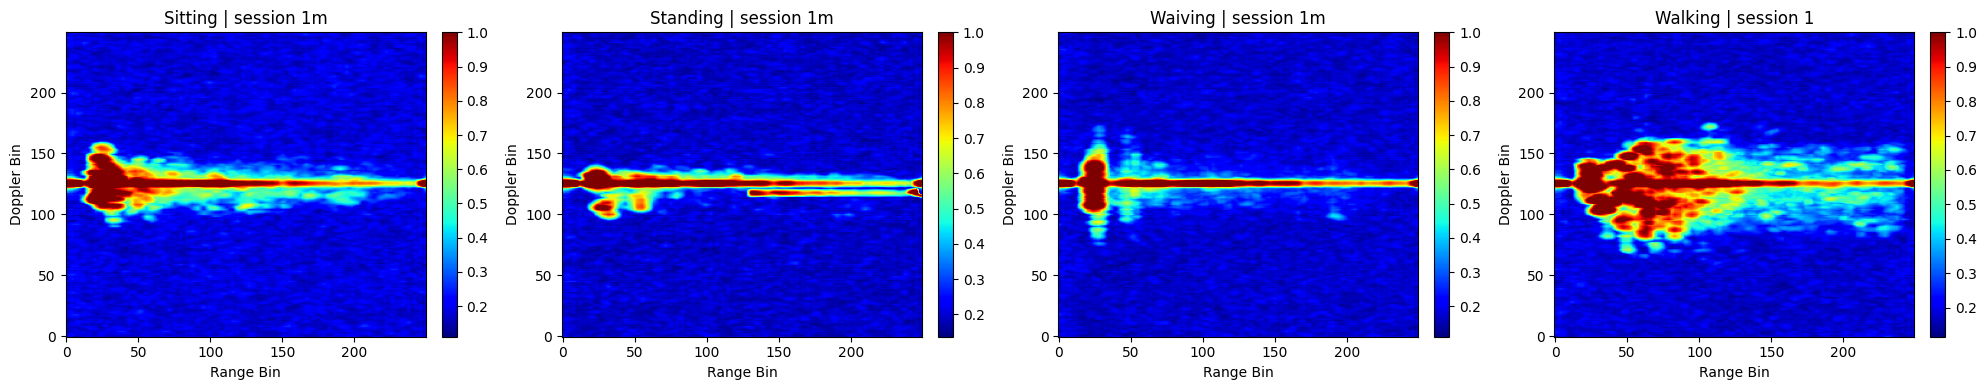

In [25]:
# Spectrogram view before model training (from preprocessed range-doppler sessions)
if "split_df" not in globals() or split_df.empty:
    print("Run Step 1 preprocessing cell first.")
else:
    acts = sorted(split_df["activity"].unique().tolist())
    fig, axes = plt.subplots(1, len(acts), figsize=(5 * len(acts), 4), squeeze=False)

    for i, act in enumerate(acts):
        ax = axes[0][i]
        row = split_df[split_df["activity"] == act].iloc[0]
        signature = np.max(row["frame_maps"], axis=0)  # [range, doppler]
        img = signature.T  # show x=range, y=doppler

        im = ax.imshow(img, origin="lower", aspect="auto", cmap="jet")
        ax.set_title(f"{act} | session {row['session']}")
        ax.set_xlabel("Range Bin")
        ax.set_ylabel("Doppler Bin")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.3533 - loss: 1.3505 - val_accuracy: 0.7385 - val_loss: 0.9987 - learning_rate: 6.0000e-04
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.6561 - loss: 1.0345 - val_accuracy: 0.7077 - val_loss: 0.8290 - learning_rate: 6.0000e-04
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.6421 - loss: 0.8880 - val_accuracy: 0.7000 - val_loss: 0.7469 - learning_rate: 6.0000e-04
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.6781 - loss: 0.7909 - val_accuracy: 0.7692 - val_loss: 0.5868 - learning_rate: 6.0000e-04
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8240 - loss: 0.6140 - val_accuracy: 0.7000 - val_loss: 0.6720 - learning_rate: 6.0000e-04
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8512 - loss: 0.5176 - val_accuracy: 0.7692 - val_loss: 0.5188 - learning_rate: 6.0000e-04
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.8774 - loss

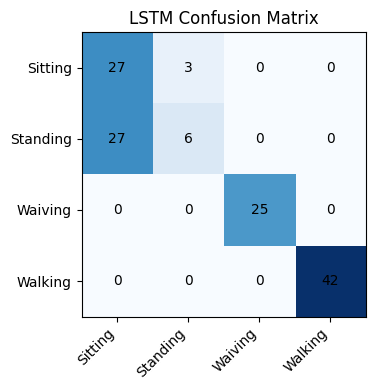

In [26]:
# Step 2: LSTM activity classification
from sklearn.utils.class_weight import compute_class_weight

classes_idx = np.arange(num_classes)
cw_lstm = compute_class_weight(class_weight="balanced", classes=classes_idx, y=y_train_enc)
class_weight_lstm = {i: float(w) for i, w in enumerate(cw_lstm)}

lstm_model = models.Sequential([
    layers.Input(shape=(X_lstm_train.shape[1], X_lstm_train.shape[2])),
    layers.Bidirectional(layers.LSTM(96, return_sequences=True, dropout=0.25)),
    layers.Bidirectional(layers.LSTM(64, dropout=0.25)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(num_classes, activation="softmax"),
])
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=6e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

cb_lstm = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
]

hist_lstm = lstm_model.fit(
    X_lstm_train,
    y_train_ohe,
    validation_data=(X_lstm_test, y_test_ohe),
    epochs=40,
    batch_size=24,
    class_weight=class_weight_lstm,
    callbacks=cb_lstm,
    verbose=1,
)

lstm_eval = lstm_model.evaluate(X_lstm_test, y_test_ohe, verbose=0)
lstm_probs = lstm_model.predict(X_lstm_test, verbose=0)
lstm_pred = np.argmax(lstm_probs, axis=1)

print("LSTM classification report")
print(classification_report(y_test_enc, lstm_pred, target_names=le.classes_, zero_division=0))

cm_lstm = confusion_matrix(y_test_enc, lstm_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm_lstm, cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.xticks(range(num_classes), le.classes_, rotation=45, ha="right")
plt.yticks(range(num_classes), le.classes_)
for i in range(cm_lstm.shape[0]):
    for j in range(cm_lstm.shape[1]):
        plt.text(j, i, cm_lstm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

Epoch 1/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.6976 - loss: 1.1109 - val_accuracy: 0.3231 - val_loss: 1.3365 - learning_rate: 7.0000e-04
Epoch 2/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.7786 - loss: 0.6893 - val_accuracy: 0.3231 - val_loss: 1.3197 - learning_rate: 7.0000e-04
Epoch 3/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.8138 - loss: 0.5995 - val_accuracy: 0.3231 - val_loss: 1.3200 - learning_rate: 7.0000e-04
Epoch 4/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8142 - loss: 0.5576 - val_accuracy: 0.3385 - val_loss: 1.3507 - learning_rate: 7.0000e-04
Epoch 5/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8393 - loss: 0.5494 - val_accuracy: 0.2462 - val_loss: 1.3873 - learning_rate: 7.0000e-04
Epoch 6/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8615 - loss: 0.5011 - val_accuracy: 0.2308 - val_loss: 1.4127 - learning_rate: 3.5000e-04
Epoch 7/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8880 - loss: 0.476

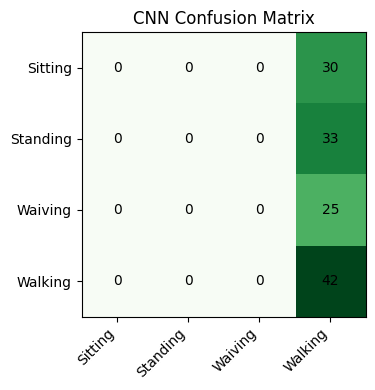

In [27]:
# Step 3: CNN activity classification
cw_cnn = compute_class_weight(class_weight="balanced", classes=classes_idx, y=y_train_enc)
class_weight_cnn = {i: float(w) for i, w in enumerate(cw_cnn)}

cnn_model = models.Sequential([
    layers.Input(shape=(X_cnn_train.shape[1], X_cnn_train.shape[2], X_cnn_train.shape[3])),
    layers.Conv2D(24, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(48, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Conv2D(96, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.35),
    layers.Dense(96, activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(num_classes, activation="softmax"),
])
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

cb_cnn = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
]

hist_cnn = cnn_model.fit(
    X_cnn_train,
    y_train_ohe,
    validation_data=(X_cnn_test, y_test_ohe),
    epochs=40,
    batch_size=20,
    class_weight=class_weight_cnn,
    callbacks=cb_cnn,
    verbose=1,
)

cnn_eval = cnn_model.evaluate(X_cnn_test, y_test_ohe, verbose=0)
cnn_probs = cnn_model.predict(X_cnn_test, verbose=0)
cnn_pred = np.argmax(cnn_probs, axis=1)

print("CNN classification report")
print(classification_report(y_test_enc, cnn_pred, target_names=le.classes_, zero_division=0))

cm_cnn = confusion_matrix(y_test_enc, cnn_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm_cnn, cmap="Greens")
plt.title("CNN Confusion Matrix")
plt.xticks(range(num_classes), le.classes_, rotation=45, ha="right")
plt.yticks(range(num_classes), le.classes_)
for i in range(cm_cnn.shape[0]):
    for j in range(cm_cnn.shape[1]):
        plt.text(j, i, cm_cnn[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

Combined model classification report


              precision    recall  f1-score   support

     Sitting       0.47      0.90      0.62        30
    Standing       0.50      0.09      0.15        33
     Waiving       1.00      1.00      1.00        25
     Walking       1.00      1.00      1.00        42

    accuracy                           0.75       130
   macro avg       0.74      0.75      0.69       130
weighted avg       0.75      0.75      0.70       130



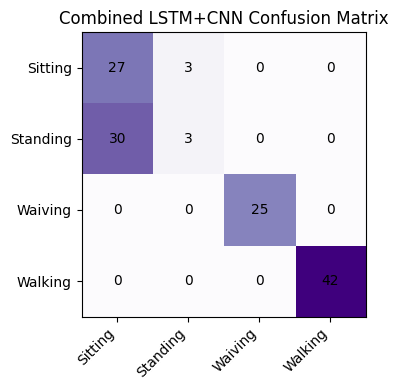

,Model,Test Loss,Test Accuracy,Macro F1
0,LSTM,0.518785,0.769231,0.732143
1,LSTM+CNN Combined,NaN,0.746154,0.693634
2,CNN,1.319716,0.323077,0.122093


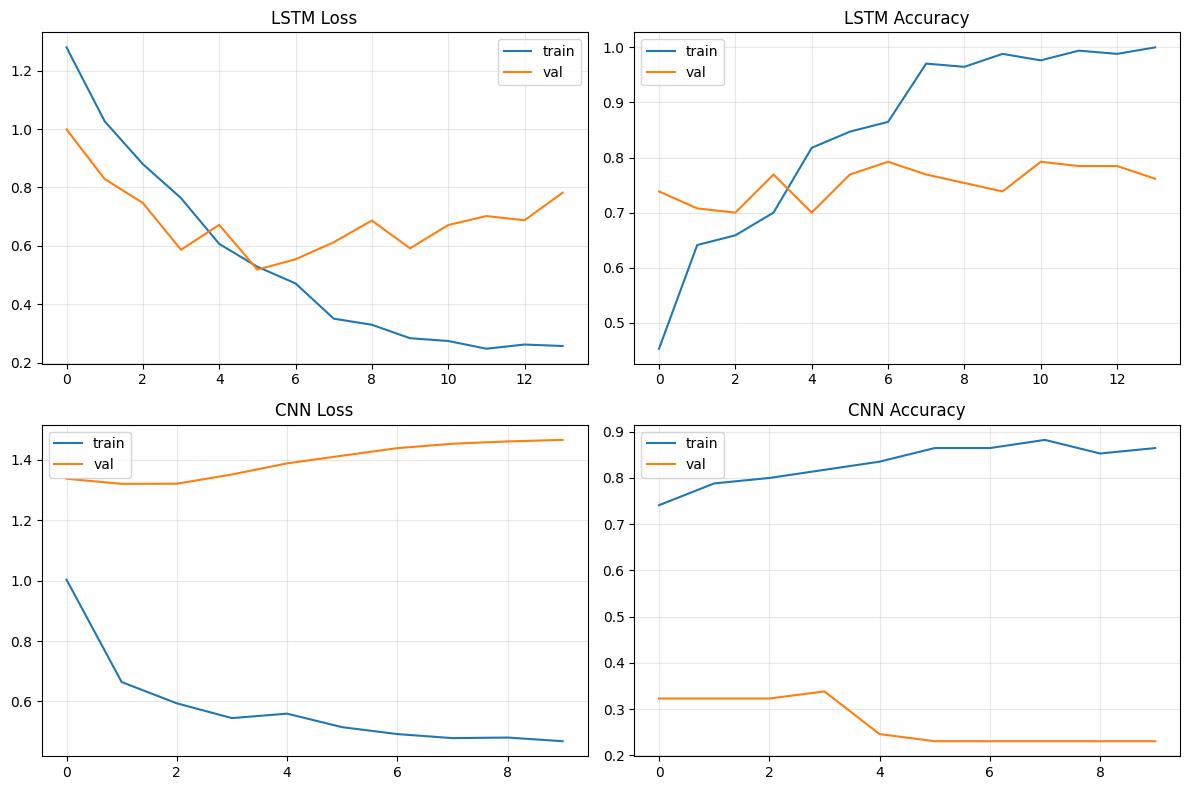

In [28]:
# Step 4: Combined LSTM + CNN activity classification (probability fusion)
fusion_alpha = 0.6
combined_probs = fusion_alpha * lstm_probs + (1.0 - fusion_alpha) * cnn_probs
combined_pred = np.argmax(combined_probs, axis=1)

print("Combined model classification report")
print(classification_report(y_test_enc, combined_pred, target_names=le.classes_, zero_division=0))

cm_comb = confusion_matrix(y_test_enc, combined_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm_comb, cmap="Purples")
plt.title("Combined LSTM+CNN Confusion Matrix")
plt.xticks(range(num_classes), le.classes_, rotation=45, ha="right")
plt.yticks(range(num_classes), le.classes_)
for i in range(cm_comb.shape[0]):
    for j in range(cm_comb.shape[1]):
        plt.text(j, i, cm_comb[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame([
    {
        "Model": "LSTM",
        "Test Loss": float(lstm_eval[0]),
        "Test Accuracy": float(lstm_eval[1]),
        "Macro F1": classification_report(y_test_enc, lstm_pred, output_dict=True, zero_division=0)["macro avg"]["f1-score"],
    },
    {
        "Model": "CNN",
        "Test Loss": float(cnn_eval[0]),
        "Test Accuracy": float(cnn_eval[1]),
        "Macro F1": classification_report(y_test_enc, cnn_pred, output_dict=True, zero_division=0)["macro avg"]["f1-score"],
    },
    {
        "Model": "LSTM+CNN Combined",
        "Test Loss": np.nan,
        "Test Accuracy": float((combined_pred == y_test_enc).mean()),
        "Macro F1": classification_report(y_test_enc, combined_pred, output_dict=True, zero_division=0)["macro avg"]["f1-score"],
    },
]).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(hist_lstm.history["loss"], label="train")
axes[0, 0].plot(hist_lstm.history["val_loss"], label="val")
axes[0, 0].set_title("LSTM Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(hist_lstm.history["accuracy"], label="train")
axes[0, 1].plot(hist_lstm.history["val_accuracy"], label="val")
axes[0, 1].set_title("LSTM Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(hist_cnn.history["loss"], label="train")
axes[1, 0].plot(hist_cnn.history["val_loss"], label="val")
axes[1, 0].set_title("CNN Loss")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(hist_cnn.history["accuracy"], label="train")
axes[1, 1].plot(hist_cnn.history["val_accuracy"], label="val")
axes[1, 1].set_title("CNN Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### How the Initial Confusion Matrix Values Are Computed

The first confusion matrices in Step 2, Step 3, and Step 4 are built from **test windows** using this logic:
- True labels: `y_test_enc`
- Predicted labels:
  - LSTM: `lstm_pred`
  - CNN: `cnn_pred`
  - Combined: `combined_pred`
- Matrix function: `confusion_matrix(y_test_enc, pred)`

So each cell value means:
- Row = actual class
- Column = predicted class
- Cell value = number of **test windows** that fall into that actual/predicted pair

---

### Train and Test Count Per Activity (Session Level)

Your split rule is session-based:
- Train sessions per activity: **3**
- Test sessions per activity: **2**
- Total sessions per activity: **5**

With 4 activities, total sessions are:
- Train sessions: `4 x 3 = 12`
- Test sessions: `4 x 2 = 8`
- All sessions: `20`

---

### Why Initial Confusion Matrix Counts Can Be Larger Than 5 Per Activity

The initial confusion matrix is **window-level**, not session-level.

Each session is converted into overlapping windows:
- `seq_len = 8`
- `stride = 2`
- Windows from one session with `F` frames:
  - `n_windows = floor((F - seq_len) / stride) + 1` (if `F >= seq_len`)

So one session contributes multiple predictions. Because of that:
- One activity contributes many test windows (from its 2 test sessions), not just 2 entries.
- Row totals in the initial confusion matrix equal the number of test windows for that activity.
- Therefore counts can be much larger than 5 even though there are only 5 sessions/activity in total.

---

### Session-Level vs Window-Level (Important)

- **Window-level confusion matrix (initial one):** evaluates every window; higher counts; detailed temporal-slice performance.
- **Session-level confusion matrix (new cell below):** one final vote per session; counts match session numbers exactly:
  - Test-only: 2 per activity
  - All sessions (train+test): 5 per activity

In [29]:
# Window-count calculation per activity (train and test)
import numpy as np
import pandas as pd

if "split_df" not in globals() or "make_windows" not in globals():
    print("Run Step 1 preprocessing cell first.")
else:
    calc_rows = []
    for _, row in split_df.iterrows():
        n_frames = int(row["frame_maps"].shape[0])
        n_windows = len(make_windows(row["frame_maps"], seq_len=SEQ_LEN, stride=STRIDE))
        formula_windows = 0 if n_frames < SEQ_LEN else ((n_frames - SEQ_LEN) // STRIDE + 1)
        calc_rows.append({
            "activity": row["activity"],
            "session": row["session"],
            "split": row["split"],
            "n_frames_kept": n_frames,
            "n_windows": n_windows,
            "n_windows_formula": int(formula_windows),
        })

    win_df = pd.DataFrame(calc_rows)
    win_df["formula_match"] = win_df["n_windows"] == win_df["n_windows_formula"]

    print("Per-session window counts:")
    display(win_df[["activity", "session", "split", "n_frames_kept", "n_windows"]].sort_values(["activity", "split", "session"]).reset_index(drop=True))

    print("Window counts per activity and split:")
    by_act_split = win_df.groupby(["activity", "split"], as_index=False)["n_windows"].sum()
    display(by_act_split.sort_values(["activity", "split"]).reset_index(drop=True))

    print("Pivot table (rows = activity, columns = split):")
    pivot = by_act_split.pivot(index="activity", columns="split", values="n_windows").fillna(0).astype(int)
    display(pivot)

    print("Total windows:")
    print("Train windows:", int(win_df[win_df["split"] == "train"]["n_windows"].sum()))
    print("Test windows:", int(win_df[win_df["split"] == "test"]["n_windows"].sum()))

Per-session window counts:


,activity,session,split,n_frames_kept,n_windows
0,Sitting,3m,test,36,15
1,Sitting,4.m,test,36,15
2,Sitting,1m,train,22,8
3,Sitting,2.5m,train,23,8
4,Sitting,2m,train,30,12
5,Standing,3m,test,38,16
6,Standing,4.m,test,41,17
7,Standing,1m,train,38,16
8,Standing,2.5m,train,36,15
9,Standing,2m,train,42,18


Window counts per activity and split:


,activity,split,n_windows
0,Sitting,test,30
1,Sitting,train,28
2,Standing,test,33
3,Standing,train,49
4,Waiving,test,25
5,Waiving,train,38
6,Walking,test,42
7,Walking,train,55


Pivot table (rows = activity, columns = split):


split,test,train
activity,,
Sitting,30,28
Standing,33,49
Waiving,25,38
Walking,42,55


Total windows:
Train windows: 170
Test windows: 130


Session counts per activity by split:


split,test,train
activity,,
Sitting,2,3
Standing,2,3
Waiving,2,3
Walking,2,3



TEST-only session-level confusion (expected: 2 sessions/activity if all present):


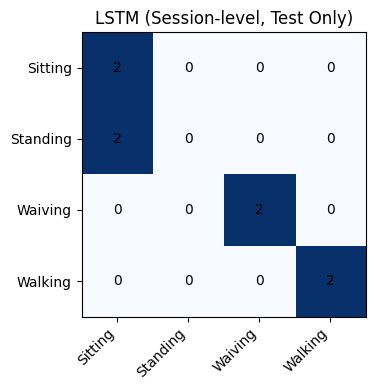

              precision    recall  f1-score   support

     Sitting       0.50      1.00      0.67         2
    Standing       0.00      0.00      0.00         2
     Waiving       1.00      1.00      1.00         2
     Walking       1.00      1.00      1.00         2

    accuracy                           0.75         8
   macro avg       0.62      0.75      0.67         8
weighted avg       0.62      0.75      0.67         8



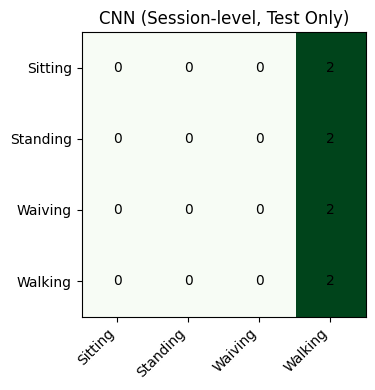

              precision    recall  f1-score   support

     Sitting       0.00      0.00      0.00         2
    Standing       0.00      0.00      0.00         2
     Waiving       0.00      0.00      0.00         2
     Walking       0.25      1.00      0.40         2

    accuracy                           0.25         8
   macro avg       0.06      0.25      0.10         8
weighted avg       0.06      0.25      0.10         8



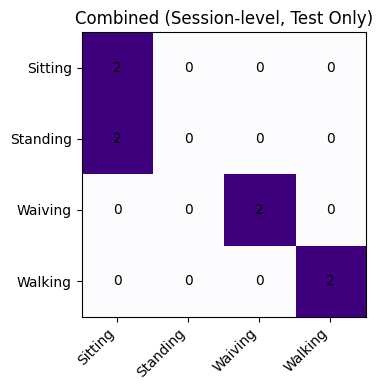

              precision    recall  f1-score   support

     Sitting       0.50      1.00      0.67         2
    Standing       0.00      0.00      0.00         2
     Waiving       1.00      1.00      1.00         2
     Walking       1.00      1.00      1.00         2

    accuracy                           0.75         8
   macro avg       0.62      0.75      0.67         8
weighted avg       0.62      0.75      0.67         8



In [30]:
# Session-level confusion matrix (one prediction per sample/session)
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

required_vars = [
    "split_df", "make_windows", "SEQ_LEN", "STRIDE", "mu", "sigma",
    "resize_seq_batch", "TARGET_HW", "lstm_model", "cnn_model", "le",
    "num_classes",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    print("Run Step 1-4 cells first. Missing:", missing)
else:
    rows = []
    for _, row in split_df.iterrows():
        windows = make_windows(row["frame_maps"], seq_len=SEQ_LEN, stride=STRIDE)
        if len(windows) == 0:
            continue

        x_seq = np.asarray(windows, dtype=np.float32)
        x_seq = (x_seq - mu) / sigma
        x_rs = resize_seq_batch(x_seq, TARGET_HW)

        # LSTM input
        x_lstm = x_rs.reshape((x_rs.shape[0], x_rs.shape[1], -1))

        # CNN input (same representation used in training cell)
        x_motion = np.mean(np.abs(np.diff(x_rs, axis=1)), axis=1)
        x_energy = np.max(x_rs, axis=1)
        x_cnn = np.stack([x_motion, x_energy], axis=-1).astype(np.float32)

        # Window-level probabilities
        p_lstm_w = lstm_model.predict(x_lstm, verbose=0)
        p_cnn_w = cnn_model.predict(x_cnn, verbose=0)
        p_comb_w = 0.6 * p_lstm_w + 0.4 * p_cnn_w

        # Session-level probability = average over windows
        p_lstm_s = p_lstm_w.mean(axis=0)
        p_cnn_s = p_cnn_w.mean(axis=0)
        p_comb_s = p_comb_w.mean(axis=0)

        rows.append({
            "activity": row["activity"],
            "session": row["session"],
            "split": row["split"],
            "true": row["activity"],
            "pred_lstm": le.classes_[int(np.argmax(p_lstm_s))],
            "pred_cnn": le.classes_[int(np.argmax(p_cnn_s))],
            "pred_comb": le.classes_[int(np.argmax(p_comb_s))],
            "n_windows": int(x_seq.shape[0]),
        })

    sample_pred_df = pd.DataFrame(rows)
    if sample_pred_df.empty:
        print("No session-level predictions could be built.")
    else:
        print("Session counts per activity by split:")
        display(sample_pred_df.groupby(["activity", "split"]).size().unstack(fill_value=0))

        # This is the true evaluation setup: test only (2 sessions/activity)
        test_df = sample_pred_df[sample_pred_df["split"] == "test"].copy()
        print("\nTEST-only session-level confusion (expected: 2 sessions/activity if all present):")
        for model_col, title, cmap in [
            ("pred_lstm", "LSTM (Session-level, Test Only)", "Blues"),
            ("pred_cnn", "CNN (Session-level, Test Only)", "Greens"),
            ("pred_comb", "Combined (Session-level, Test Only)", "Purples"),
        ]:
            y_true = pd.Categorical(test_df["true"], categories=le.classes_).codes
            y_pred = pd.Categorical(test_df[model_col], categories=le.classes_).codes
            cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

            plt.figure(figsize=(5, 4))
            plt.imshow(cm, cmap=cmap)
            plt.title(title)
            plt.xticks(range(num_classes), le.classes_, rotation=45, ha="right")
            plt.yticks(range(num_classes), le.classes_)
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
            plt.tight_layout()
            plt.show()

            print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

        